# Actividad 4 - Semana 5
## Regresion lineal multiple y regresion logistica binaria

Este notebook resuelve las dos partes de la actividad:

1. Prediccion del precio de venta de vehiculos con regresion lineal multiple.
2. Analisis de sobrevivencia en el Titanic con regresion logistica binaria.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import ttest_ind
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

In [2]:
data_dir = Path("data")
vehicle_path = data_dir / "car_prices.csv"
titanic_path = data_dir / "titanic_openml.csv"

print("Vehiculos:", vehicle_path.resolve())
print("Titanic:", titanic_path.resolve())
print("Archivo vehiculos existe:", vehicle_path.exists())
print("Archivo Titanic existe:", titanic_path.exists())

Vehiculos: /Users/patopina/data_science/semanas/semana5/actividad/data/car_prices.csv
Titanic: /Users/patopina/data_science/semanas/semana5/actividad/data/titanic_openml.csv
Archivo vehiculos existe: True
Archivo Titanic existe: True


# Parte 1. Prediccion de ventas usando regresion lineal multiple

En esta seccion se construye un modelo para estimar `sellingprice` con base en el precio de referencia del mercado (`mmr`) y el kilometraje (`odometer`).

## 1. Preparacion de los datos

Se carga el dataset de vehiculos desde la carpeta local `data/`.

In [3]:
vehicles = pd.read_csv(vehicle_path)

print("Dimensiones:", vehicles.shape)
vehicles.head()

Dimensiones: (558837, 16)


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.000,"16,639.000",white,black,kia motors america inc,"20,500.000","21,500.000",Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.000,"9,393.000",white,beige,kia motors america inc,"20,800.000","21,500.000",Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.000,"1,331.000",gray,black,financial services remarketing (lease),"31,900.000","30,000.000",Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.000,"14,282.000",white,black,volvo na rep/world omni,"27,500.000","27,750.000",Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.000,"2,641.000",gray,black,financial services remarketing (lease),"66,000.000","67,000.000",Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


## 2. Inspeccion y limpieza

Se seleccionan las columnas utiles para el modelo y se eliminan nulos y duplicados en el subconjunto de trabajo.

In [4]:
vehicle_cols = ["sellingprice", "mmr", "odometer", "year", "condition"]
vehicles_model = vehicles[vehicle_cols].copy()

print("Valores nulos antes de limpiar:")
print(vehicles_model.isna().sum())

vehicles_model = vehicles_model.dropna().drop_duplicates()

print("\nDimensiones despues de limpiar:", vehicles_model.shape)
vehicles_model.describe().T

Valores nulos antes de limpiar:
sellingprice       12
mmr                38
odometer           94
year                0
condition       11820
dtype: int64

Dimensiones despues de limpiar: (546972, 5)


,count,mean,std,min,25%,50%,75%,max
sellingprice,"546,972.000","13,764.495","9,747.817",1.000,"7,100.000","12,300.000","18,300.000","230,000.000"
mmr,"546,972.000","13,915.761","9,674.427",25.000,"7,375.000","12,400.000","18,450.000","182,000.000"
odometer,"546,972.000","67,263.712","52,793.489",1.000,"28,051.000","51,223.000","97,393.250","999,999.000"
year,"546,972.000","2,010.134",3.906,"1,982.000","2,008.000","2,012.000","2,013.000","2,015.000"
condition,"546,972.000",30.673,13.403,1.000,23.000,35.000,42.000,49.000


## 3. Analisis exploratorio

La grafica `pairplot` permite revisar la relacion entre el precio de venta, el precio de referencia (`mmr`) y el kilometraje. Como el dataset es grande, se usa una muestra aleatoria para que la visualizacion sea manejable.

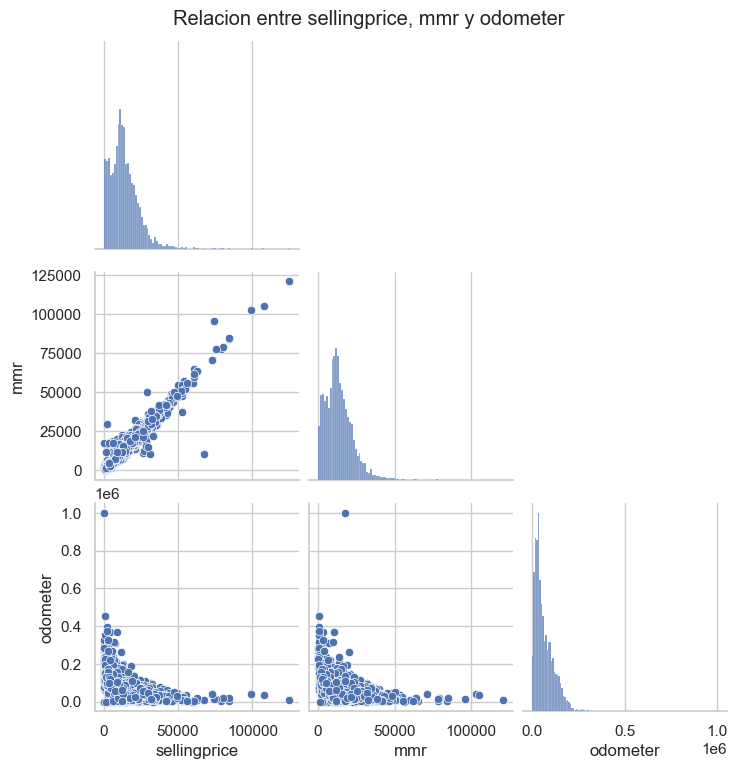

In [5]:
pairplot_sample = vehicles_model[["sellingprice", "mmr", "odometer"]].sample(
    n=min(5000, len(vehicles_model)),
    random_state=42,
)

sns.pairplot(pairplot_sample, corner=True, diag_kind="hist")
plt.suptitle("Relacion entre sellingprice, mmr y odometer", y=1.02)
plt.show()

## 4. Identificacion de variables

- Variable dependiente: `sellingprice`
- Variables independientes: `mmr`, `odometer`

In [6]:
X_vehicle = vehicles_model[["mmr", "odometer"]]
y_vehicle = vehicles_model["sellingprice"]

print("Variables independientes:", X_vehicle.columns.tolist())
print("Variable dependiente:", y_vehicle.name)

Variables independientes: ['mmr', 'odometer']
Variable dependiente: sellingprice


## 5. Division de datos

Se separan conjuntos de entrenamiento y prueba para evaluar la capacidad de generalizacion del modelo.

In [7]:
X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_vehicle,
    y_vehicle,
    test_size=0.20,
    random_state=42,
)

print("X_train:", X_train_v.shape)
print("X_test:", X_test_v.shape)
print("y_train:", y_train_v.shape)
print("y_test:", y_test_v.shape)

X_train: (437577, 2)
X_test: (109395, 2)
y_train: (437577,)
y_test: (109395,)


## 6. Modelado

Se ajusta un modelo de regresion lineal multiple.

In [8]:
linear_model = LinearRegression()
linear_model.fit(X_train_v, y_train_v)

coef_df = pd.DataFrame(
    {
        "variable": X_vehicle.columns,
        "coeficiente": linear_model.coef_,
    }
)

print("Intercepto:", linear_model.intercept_)
coef_df

Intercepto: 100.4715253818922


,variable,coeficiente
0,mmr,0.988
1,odometer,-0.001


## 7. Evaluacion del modelo y prediccion

Se calculan las predicciones sobre el conjunto de prueba y se evalua el ajuste con `R^2` y error cuadratico medio.

In [9]:
y_pred_v = linear_model.predict(X_test_v)

vehicle_r2 = r2_score(y_test_v, y_pred_v)
vehicle_mse = mean_squared_error(y_test_v, y_pred_v)
vehicle_rmse = np.sqrt(vehicle_mse)

print(f"R^2: {vehicle_r2:.4f}")
print(f"MSE: {vehicle_mse:,.2f}")
print(f"RMSE: {vehicle_rmse:,.2f}")

predictions_vehicle = pd.DataFrame(
    {
        "valor_real": y_test_v.values,
        "valor_predicho": y_pred_v,
        "error": y_test_v.values - y_pred_v,
    }
)
predictions_vehicle.head(10)

R^2: 0.9686
MSE: 2,996,153.80
RMSE: 1,730.94


,valor_real,valor_predicho,error
0,"15,000.000","9,952.922","5,047.078"
1,"19,700.000","19,456.121",243.879
2,"15,500.000","14,262.930","1,237.070"
3,400.000,"2,409.781","-2,009.781"
4,"14,200.000","13,976.022",223.978
5,"10,400.000","8,633.810","1,766.190"
6,"17,900.000","17,536.187",363.813
7,"7,600.000","7,147.092",452.908
8,"10,900.000","9,677.673","1,222.327"
9,"12,500.000","11,577.969",922.031


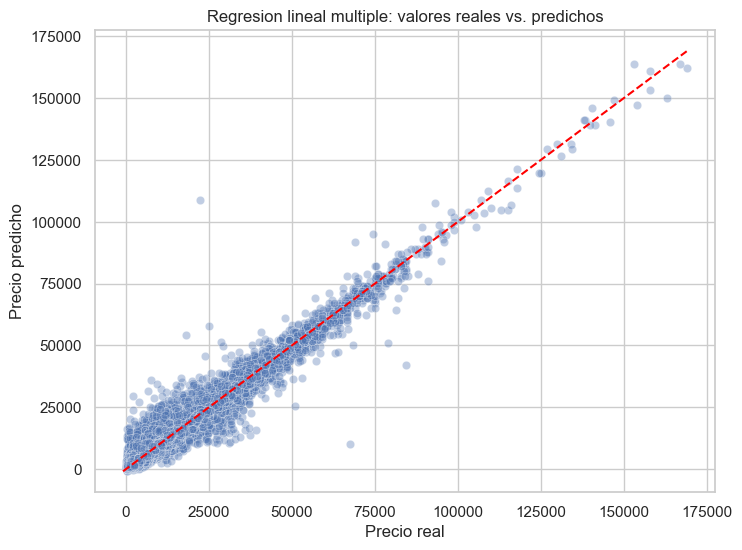

In [10]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_v, y=y_pred_v, alpha=0.35)
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Regresion lineal multiple: valores reales vs. predichos")

lims = [
    min(y_test_v.min(), y_pred_v.min()),
    max(y_test_v.max(), y_pred_v.max()),
]
plt.plot(lims, lims, color="red", linestyle="--")
plt.show()

## 8. Conclusion de la parte 1

La siguiente celda genera una conclusion automatizada con base en las metricas obtenidas y el signo de los coeficientes del modelo.

In [11]:
coef_mmr = float(coef_df.loc[coef_df["variable"] == "mmr", "coeficiente"].iloc[0])
coef_odometer = float(coef_df.loc[coef_df["variable"] == "odometer", "coeficiente"].iloc[0])

print("Conclusiones parte 1:")
print(f"- El modelo explica aproximadamente el {vehicle_r2:.2%} de la variabilidad del precio de venta.")
print(f"- El coeficiente de 'mmr' es {coef_mmr:,.3f}, por lo que cuando el precio de mercado sube, el precio de venta esperado tambien tiende a subir.")
print(f"- El coeficiente de 'odometer' es {coef_odometer:,.3f}, lo que sugiere que un mayor kilometraje reduce el precio esperado de venta.")
print(f"- El RMSE de {vehicle_rmse:,.2f} indica el tamano promedio del error en unidades monetarias.")
print("- Una mejora futura seria incorporar variables adicionales como anio, condicion, marca o transmision para capturar mejor la variacion del precio.")

Conclusiones parte 1:
- El modelo explica aproximadamente el 96.86% de la variabilidad del precio de venta.
- El coeficiente de 'mmr' es 0.988, por lo que cuando el precio de mercado sube, el precio de venta esperado tambien tiende a subir.
- El coeficiente de 'odometer' es -0.001, lo que sugiere que un mayor kilometraje reduce el precio esperado de venta.
- El RMSE de 1,730.94 indica el tamano promedio del error en unidades monetarias.
- Una mejora futura seria incorporar variables adicionales como anio, condicion, marca o transmision para capturar mejor la variacion del precio.


# Parte 2. Analisis de sobrevivencia en el Titanic con regresion logistica binaria

En esta seccion se determina que variables son mas utiles para predecir la sobrevivencia de los pasajeros.

## 1. Preparacion de los datos

Se carga la base del Titanic desde `data/titanic_openml.csv`.

In [12]:
titanic = pd.read_csv(titanic_path, na_values=["?"])

print("Dimensiones:", titanic.shape)
titanic.head()

Dimensiones: (1309, 14)


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.000,0,0,24160,211.338,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.917,1,2,113781,151.550,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.000,1,2,113781,151.550,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.000,1,2,113781,151.550,C22 C26,S,NaN,135.000,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.000,1,2,113781,151.550,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## 2. Limpieza de datos

Se eliminan columnas poco utiles para el modelo por alta cardinalidad, fuga de informacion o exceso de nulos, y despues se eliminan registros faltantes.

In [13]:
print("Columnas originales:")
print(titanic.columns.tolist())

drop_cols = ["name", "ticket", "cabin", "boat", "body", "home.dest"]
titanic_clean = titanic.drop(columns=drop_cols).copy()

print("\nValores nulos antes de limpiar:")
print(titanic_clean.isna().sum())

titanic_clean = titanic_clean.dropna().copy()

print("\nDimensiones despues de limpiar:", titanic_clean.shape)
titanic_clean.head()

Columnas originales:
['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest']

Valores nulos antes de limpiar:
pclass        0
survived      0
sex           0
age         263
sibsp         0
parch         0
fare          1
embarked      2
dtype: int64

Dimensiones despues de limpiar: (1043, 8)


,pclass,survived,sex,age,sibsp,parch,fare,embarked
0,1,1,female,29.000,0,0,211.338,S
1,1,1,male,0.917,1,2,151.550,S
2,1,0,female,2.000,1,2,151.550,S
3,1,0,male,30.000,1,2,151.550,S
4,1,0,female,25.000,1,2,151.550,S


## 3. Conversion de variables al formato correcto

Se ajustan tipos numericos y categoricos para dejar lista la base antes del modelado.

In [14]:
titanic_clean["survived"] = titanic_clean["survived"].astype(int)
titanic_clean["pclass"] = titanic_clean["pclass"].astype(int)
titanic_clean["sibsp"] = titanic_clean["sibsp"].astype(int)
titanic_clean["parch"] = titanic_clean["parch"].astype(int)
titanic_clean["age"] = titanic_clean["age"].astype(float)
titanic_clean["fare"] = titanic_clean["fare"].astype(float)
titanic_clean["sex"] = titanic_clean["sex"].astype("category")
titanic_clean["embarked"] = titanic_clean["embarked"].astype("category")

titanic_clean.info()

<class 'pandas.DataFrame'>
Index: 1043 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    1043 non-null   int64   
 1   survived  1043 non-null   int64   
 2   sex       1043 non-null   category
 3   age       1043 non-null   float64 
 4   sibsp     1043 non-null   int64   
 5   parch     1043 non-null   int64   
 6   fare      1043 non-null   float64 
 7   embarked  1043 non-null   category
dtypes: category(2), float64(2), int64(4)
memory usage: 59.1 KB


## 4. Visualizacion de datos

Se muestran graficas para revisar la relacion entre la sobrevivencia y algunas variables explicativas.

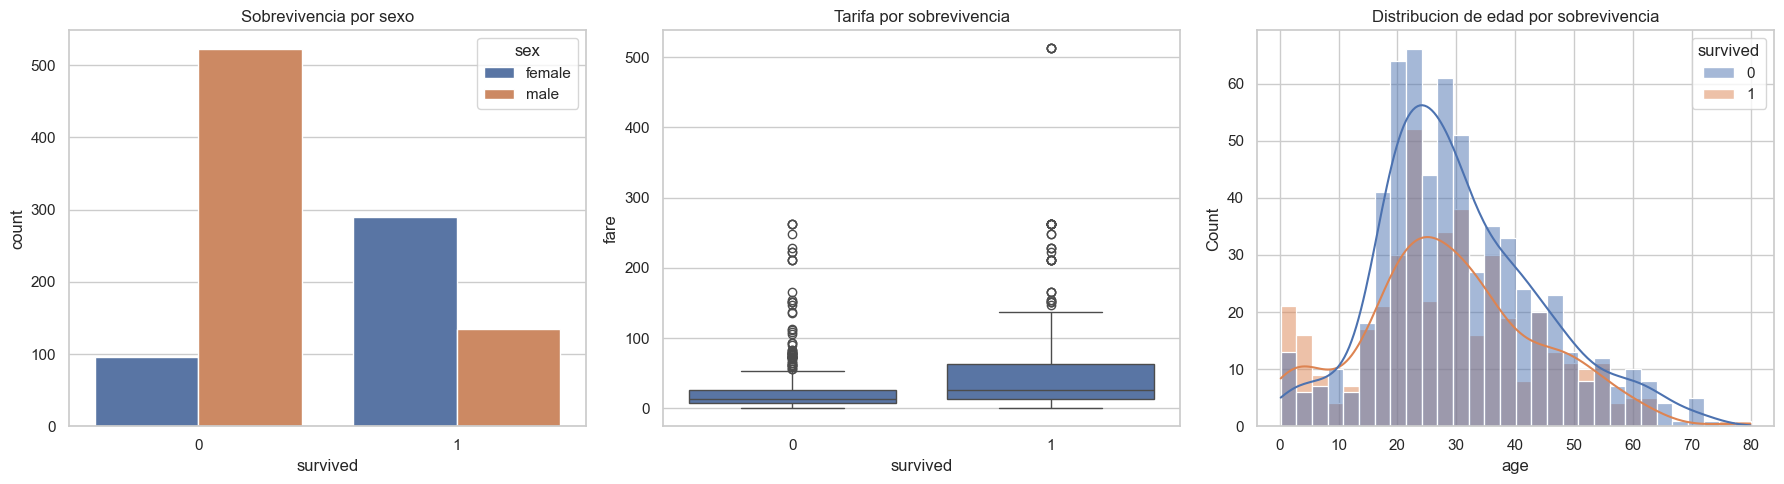

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=titanic_clean, x="survived", hue="sex", ax=axes[0])
axes[0].set_title("Sobrevivencia por sexo")

sns.boxplot(data=titanic_clean, x="survived", y="fare", ax=axes[1])
axes[1].set_title("Tarifa por sobrevivencia")

sns.histplot(data=titanic_clean, x="age", hue="survived", bins=30, kde=True, ax=axes[2])
axes[2].set_title("Distribucion de edad por sobrevivencia")

plt.tight_layout()
plt.show()

## 5. Prueba t-test

Se compara la media de `fare` entre pasajeros que sobrevivieron y pasajeros que no sobrevivieron.

In [16]:
fare_survived = titanic_clean.loc[titanic_clean["survived"] == 1, "fare"]
fare_not_survived = titanic_clean.loc[titanic_clean["survived"] == 0, "fare"]

ttest_stat, ttest_pvalue = ttest_ind(
    fare_survived,
    fare_not_survived,
    equal_var=False,
)

print(f"Media fare sobrevivientes: {fare_survived.mean():.3f}")
print(f"Media fare no sobrevivientes: {fare_not_survived.mean():.3f}")
print(f"t-statistic: {ttest_stat:.4f}")
print(f"p-value: {ttest_pvalue:.6f}")

Media fare sobrevivientes: 53.259
Media fare no sobrevivientes: 25.149
t-statistic: 7.3731
p-value: 0.000000


## 6. Division de datos

Se preparan variables predictoras y variable objetivo, codificando las categoricas con variables dummy.

In [17]:
X_titanic = pd.get_dummies(
    titanic_clean[["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]],
    drop_first=True,
)
y_titanic = titanic_clean["survived"]

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_titanic,
    y_titanic,
    test_size=0.20,
    random_state=42,
    stratify=y_titanic,
)

print("X_train:", X_train_t.shape)
print("X_test:", X_test_t.shape)
print("Columnas del modelo:")
print(X_titanic.columns.tolist())

X_train: (834, 8)
X_test: (209, 8)
Columnas del modelo:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q', 'embarked_S']


## 7. Creacion del modelo

Se entrena un modelo de regresion logistica binaria para predecir la sobrevivencia.

In [18]:
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_t, y_train_t)

y_pred_t = logistic_model.predict(X_test_t)
y_prob_t = logistic_model.predict_proba(X_test_t)[:, 1]

print(f"Accuracy: {accuracy_score(y_test_t, y_pred_t):.4f}")
print(f"Precision: {precision_score(y_test_t, y_pred_t):.4f}")
print(f"Recall: {recall_score(y_test_t, y_pred_t):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test_t, y_prob_t):.4f}")
print("\nMatriz de confusion:")
print(confusion_matrix(y_test_t, y_pred_t))

Accuracy: 0.7703
Precision: 0.7606
Recall: 0.6353
ROC AUC: 0.8371

Matriz de confusion:
[[107  17]
 [ 31  54]]


## 8. Estimacion de coeficientes y odds ratio

Los coeficientes positivos aumentan la probabilidad de sobrevivir; los negativos la reducen. El `odds_ratio` se obtiene con `exp(coeficiente)`.

In [19]:
coef_logit = pd.DataFrame(
    {
        "variable": X_titanic.columns,
        "coeficiente": logistic_model.coef_[0],
    }
)
coef_logit["odds_ratio"] = np.exp(coef_logit["coeficiente"])
coef_logit = coef_logit.sort_values("odds_ratio", ascending=False)

coef_logit

,variable,coeficiente,odds_ratio
3,parch,0.024,1.024
4,fare,0.002,1.002
1,age,-0.035,0.965
2,sibsp,-0.338,0.714
7,embarked_S,-0.433,0.649
0,pclass,-0.946,0.388
6,embarked_Q,-0.961,0.382
5,sex_male,-2.545,0.078


In [20]:
predictions_titanic = X_test_t.copy()
predictions_titanic["survived_real"] = y_test_t.values
predictions_titanic["survived_pred"] = y_pred_t
predictions_titanic["prob_survived"] = y_prob_t

predictions_titanic.head(10)

,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S,survived_real,survived_pred,prob_survived
1306,3,26.500,0,0,7.225,True,False,False,0,0,0.167
974,3,30.000,1,0,16.100,True,False,True,0,0,0.077
937,3,1.000,1,1,12.183,False,False,True,0,1,0.751
29,1,28.000,0,0,26.550,True,False,True,1,0,0.461
474,2,31.000,0,0,10.500,True,False,True,0,0,0.224
13,1,26.000,0,0,78.850,False,False,True,1,1,0.930
427,2,0.667,1,1,14.500,True,False,True,1,0,0.383
482,2,17.000,0,0,12.000,False,False,False,1,1,0.903
127,1,35.000,1,0,53.100,False,False,True,1,1,0.866
310,1,57.000,1,1,164.867,True,False,True,0,0,0.236


## 9. Conclusion de la parte 2

La siguiente celda resume los hallazgos principales del modelo logistico.

In [21]:
top_positive = coef_logit.head(3)[["variable", "odds_ratio"]]
top_negative = coef_logit.tail(3)[["variable", "odds_ratio"]].sort_values("odds_ratio")

print("Conclusiones parte 2:")
if ttest_pvalue < 0.05:
    print("- El t-test sugiere una diferencia estadisticamente significativa en la tarifa promedio entre quienes sobrevivieron y quienes no sobrevivieron.")
else:
    print("- El t-test no muestra una diferencia estadisticamente significativa en la tarifa promedio entre los grupos.")

print(f"- El modelo logistico alcanza una exactitud de {accuracy_score(y_test_t, y_pred_t):.2%} y un ROC AUC de {roc_auc_score(y_test_t, y_prob_t):.2%}.")
print("- Variables con mayor efecto positivo sobre la sobrevivencia:")
for _, row in top_positive.iterrows():
    print(f"  * {row['variable']}: odds ratio = {row['odds_ratio']:.3f}")

print("- Variables con mayor efecto negativo sobre la sobrevivencia:")
for _, row in top_negative.iterrows():
    print(f"  * {row['variable']}: odds ratio = {row['odds_ratio']:.3f}")

print("- En terminos practicos, sexo, clase, tarifa y edad aportan informacion relevante para explicar la probabilidad de sobrevivencia.")
print("- Como mejora futura, se podrian probar interacciones entre variables, escalamiento o validacion cruzada para robustecer la interpretacion del modelo.")

Conclusiones parte 2:
- El t-test sugiere una diferencia estadisticamente significativa en la tarifa promedio entre quienes sobrevivieron y quienes no sobrevivieron.
- El modelo logistico alcanza una exactitud de 77.03% y un ROC AUC de 83.71%.
- Variables con mayor efecto positivo sobre la sobrevivencia:
  * parch: odds ratio = 1.024
  * fare: odds ratio = 1.002
  * age: odds ratio = 0.965
- Variables con mayor efecto negativo sobre la sobrevivencia:
  * sex_male: odds ratio = 0.078
  * embarked_Q: odds ratio = 0.382
  * pclass: odds ratio = 0.388
- En terminos practicos, sexo, clase, tarifa y edad aportan informacion relevante para explicar la probabilidad de sobrevivencia.
- Como mejora futura, se podrian probar interacciones entre variables, escalamiento o validacion cruzada para robustecer la interpretacion del modelo.
